In [25]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [30]:
from ucimlrepo import fetch_ucirepo

try:
    dataset = fetch_ucirepo(id=891)
    # Create pandas DataFrame
    df = dataset.data.original
except ConnectionError as e: # In case of ucimlrepo failure
    print(f"An error occurred while fetching the dataset: {e}")
    print("Trying with local CSV file...")
    
    import pandas as pd
    df = pd.read_csv("dataset\diabetes_binary_health_indicators_BRFSS2015.csv")

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Teo\AppData\Local\Temp\ipykernel_18344\1291143178.py:12: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("dataset\diabetes_binary_health_indicators_BRFSS2015.csv")


In [3]:
df.head()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0,1,1,1,40,1,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,1,0,0,0,0,25,1,0,0,1,...,0,1,3,0,0,0,0,7,6,1
2,2,0,1,1,1,28,0,0,0,0,...,1,1,5,30,30,1,0,9,4,8
3,3,0,1,0,1,27,0,0,0,1,...,1,0,2,0,0,0,0,11,3,6
4,4,0,1,1,1,24,0,0,0,1,...,1,0,2,3,0,0,0,11,5,4


In [31]:
df.dtypes

ID                      int64
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [5]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [32]:
# Separate features and target variable
try:
    features = df.drop(columns=["ID", "Diabetes_binary"])
except Exception as e: # In case of ucimlrepo failure
    print(f"An error occurred while dropping columns: {e}")
    features = df.drop(columns=["Diabetes_binary"])
features.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [7]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64", "float64"]).columns 
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


# PCA

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


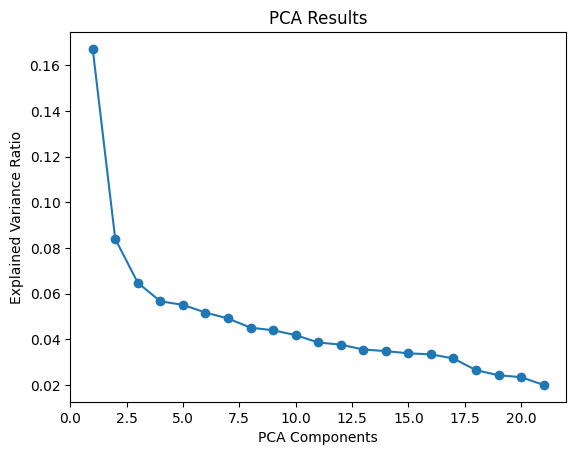

In [9]:
import matplotlib.pyplot as plt

pca = PCA().fit(scaled_data)

plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.show()

In [10]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [11]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 85% variance: 14


In [12]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


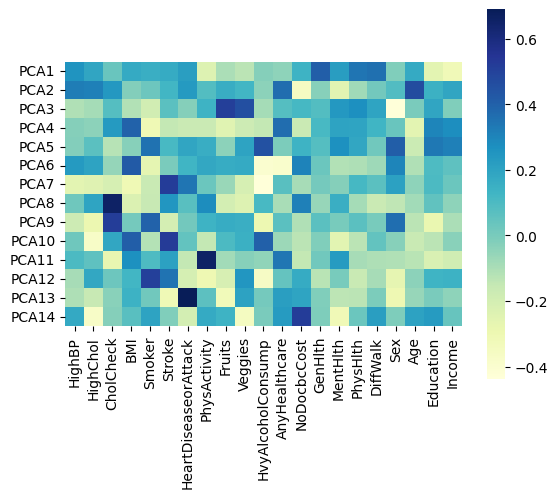

In [13]:
import seaborn as sns

ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")

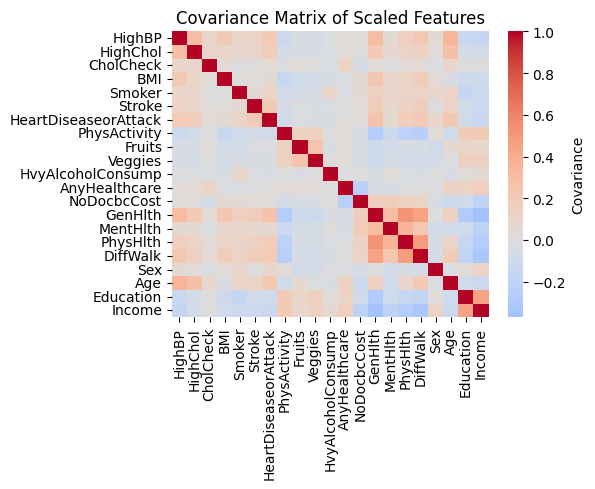

Covariance matrix shape: (21, 21)


In [14]:
import numpy as np

# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

È stato necessario selezionare parecchie componenti princiapli perchè, come si nota dalla matrice di covarianza, abbiamo in generale una bassa correlazione tra le feature.

# Neural Network

In [15]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


## PCA + Original Features

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8607 - loss: 0.3310
Epoch 2/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8607 - loss: 0.3310
Epoch 2/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8649 - loss: 0.3194
Epoch 3/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8649 - loss: 0.3194
Epoch 3/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8651 - loss: 0.3184
Epoch 4/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8651 - loss: 0.3184
Epoch 4/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8653 - loss: 0.3179
Epoch 5/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8653 - loss: 0.3179
Epoch 5/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8651 - loss: 0.3176
Epoch 6/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8651 - loss: 0.3176
Epoch 6/30
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8652 - loss: 0.3173
Epoch 7/30
2775/2775 ━━━━━━━━━━━

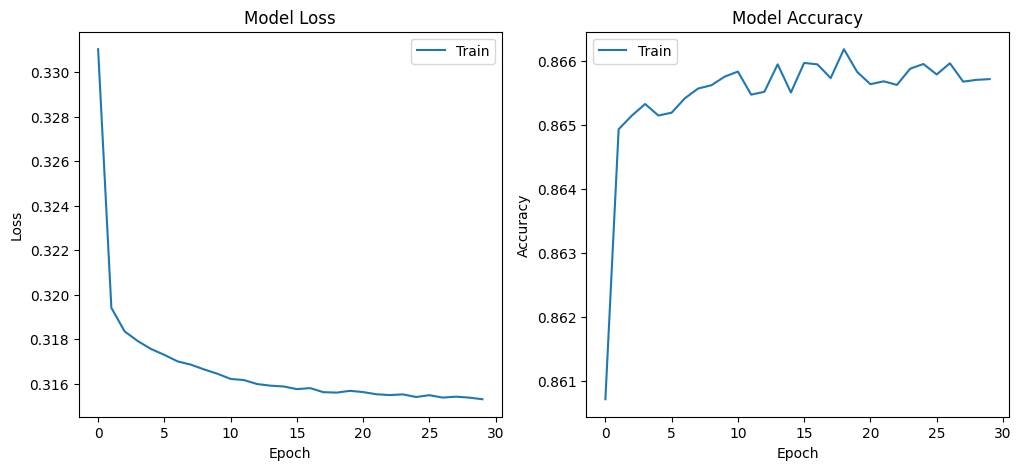

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step


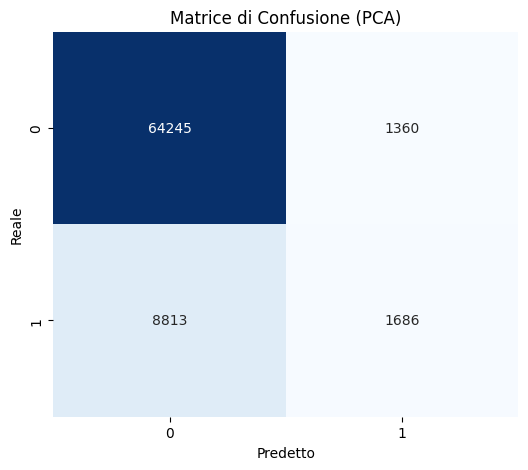

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     65605
           1       0.55      0.16      0.25     10499

    accuracy                           0.87     76104
   macro avg       0.72      0.57      0.59     76104
weighted avg       0.83      0.87      0.83     76104



In [17]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report

# 1. Data Preparation
X = pca_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Creazione del Modello
model = Sequential()

# Strato Nascosto
model.add(Dense(16, input_shape=(14,), activation="relu"))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 4. Addestramento
history = model.fit(X_train, y_train, epochs=30, batch_size=64, verbose=1)

# 5. Grafici
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train")
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 6. Valutazione
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (PCA)")
plt.show()

print(classification_report(y_test, y_pred))

## PCA + Undersampling

Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24847), np.int64(1): np.int64(24847)}
Epoch 1/30


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


699/699 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7214 - loss: 0.5489 - val_accuracy: 0.7533 - val_loss: 0.5143
Epoch 2/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7214 - loss: 0.5489 - val_accuracy: 0.7533 - val_loss: 0.5143
Epoch 2/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7414 - loss: 0.5186 - val_accuracy: 0.7539 - val_loss: 0.5101
Epoch 3/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7414 - loss: 0.5186 - val_accuracy: 0.7539 - val_loss: 0.5101
Epoch 3/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7431 - loss: 0.5155 - val_accuracy: 0.7533 - val_loss: 0.5084
Epoch 4/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7431 - loss: 0.5155 - val_accuracy: 0.7533 - val_loss: 0.5084
Epoch 4/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7441 - loss: 0.5140 - val_accuracy: 0.7547 - val_loss: 0.5077
Epoch 5/30
699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7441 - loss: 0.5140 - val_accuracy: 0.7547 - val_

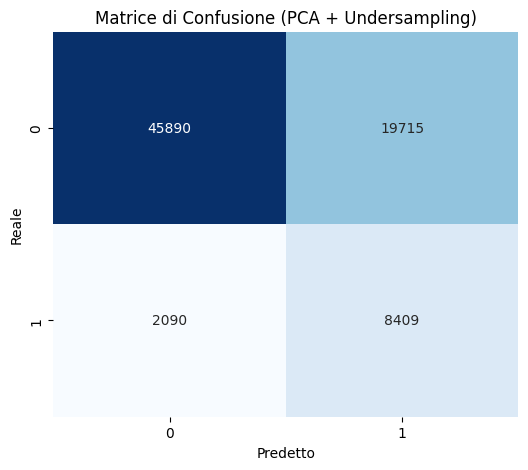

              precision    recall  f1-score   support

           0       0.96      0.70      0.81     65605
           1       0.30      0.80      0.44     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.76     76104



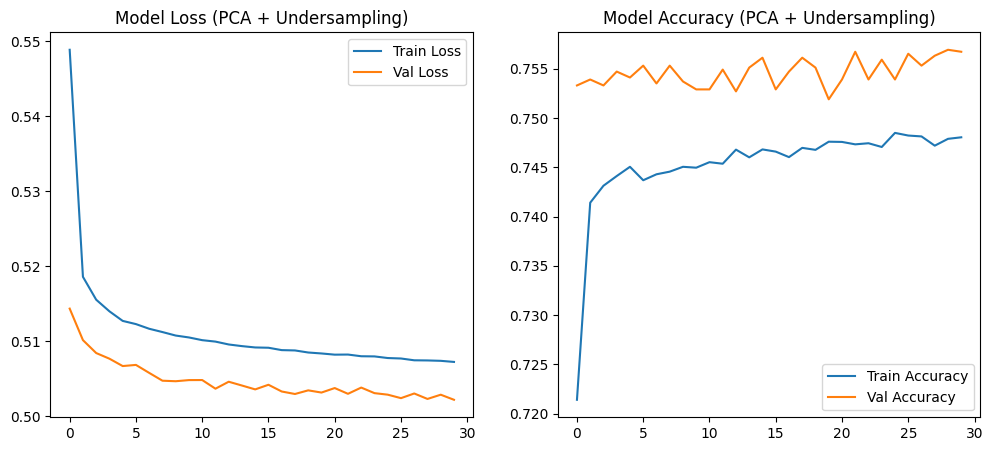

In [18]:
# 1. Data Preparation
X = pca_data
y = df["Diabetes_binary"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Undersampling
idx_minority = np.where(y_train == 1)[0]
idx_majority = np.where(y_train == 0)[0]

n_minority = len(idx_minority)

idx_majority_downsampled = np.random.choice(
    idx_majority, size=n_minority, replace=False
)

idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
np.random.shuffle(idx_balanced)

X_train_bal = X_train[idx_balanced]
y_train_bal = y_train[idx_balanced]

print("Distribuzione classi nel Training Set bilanciato:")
unique, counts = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique, counts)))

# 3. Creazione del Modello
model_pca_under = Sequential()
model_pca_under.add(Dense(16, input_shape=(14,), activation="relu"))
model_pca_under.add(Dense(1, activation="sigmoid"))

model_pca_under.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# 4. Addestramento
history_pca_under = model_pca_under.fit(
    X_train_bal, y_train_bal, epochs=30, batch_size=64, 
    verbose=1, validation_split=0.1
)

# 5. Valutazione
y_pred_probs = model_pca_under.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (PCA + Undersampling)")
plt.show()

print(classification_report(y_test, y_pred))

# 6. Grafici di training
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_pca_under.history['loss'], label='Train Loss')
plt.plot(history_pca_under.history['val_loss'], label='Val Loss')
plt.title('Model Loss (PCA + Undersampling)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pca_under.history['accuracy'], label='Train Accuracy')
plt.plot(history_pca_under.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (PCA + Undersampling)')
plt.legend()
plt.show()

## PCA + Class Weights

Dimensioni Training Set: (177576, 14)
Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/30
Epoch 1/30


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7041 - loss: 0.5389 - val_accuracy: 0.6992 - val_loss: 0.5380
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7041 - loss: 0.5389 - val_accuracy: 0.6992 - val_loss: 0.5380
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7074 - loss: 0.5161 - val_accuracy: 0.6934 - val_loss: 0.5443
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7074 - loss: 0.5161 - val_accuracy: 0.6934 - val_loss: 0.5443
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7075 - loss: 0.5134 - val_accuracy: 0.7156 - val_loss: 0.5129
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7075 - loss: 0.5134 - val_accuracy: 0.7156 - val_loss: 0.5129
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7101 - loss: 0.5121 - val_accuracy: 0.6996 - val_loss: 0.5308
Epoch 5/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7101 - loss: 0.5121 - val_accurac

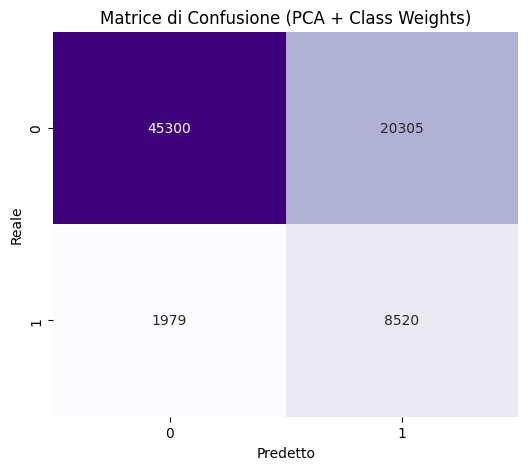

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     65605
           1       0.30      0.81      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



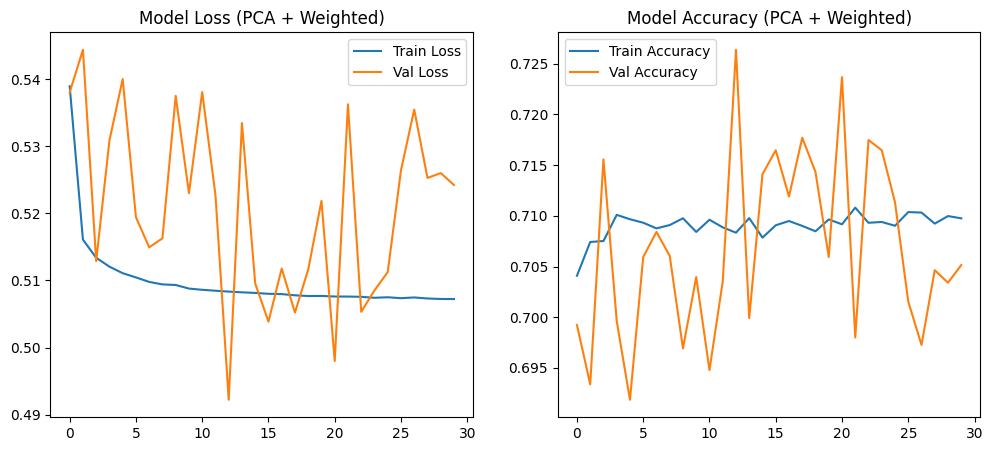

In [20]:
from sklearn.utils import class_weight

# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_pca),
    y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(16, input_shape=(14,), activation="relu"))
model_pca_weighted.add(Dense(1, activation="sigmoid"))

model_pca_weighted.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# 4. Addestramento con Class Weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca, y_train_pca,
    epochs=30, batch_size=64, verbose=1,
    validation_split=0.1,
    class_weight=class_weights
)

# 5. Valutazione
y_pred_probs_weighted = model_pca_weighted.predict(X_test_pca)
y_pred_weighted = (y_pred_probs_weighted > 0.5).astype("int32")

cm_weighted = confusion_matrix(y_test_pca, y_pred_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (PCA + Class Weights)")
plt.show()

print("Report di Classificazione:")
print(classification_report(y_test_pca, y_pred_weighted))

# 6. Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_pca_weighted.history['loss'], label='Train Loss')
plt.plot(history_pca_weighted.history['val_loss'], label='Val Loss')
plt.title('Model Loss (PCA + Weighted)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pca_weighted.history['accuracy'], label='Train Accuracy')
plt.plot(history_pca_weighted.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (PCA + Weighted)')
plt.legend()
plt.show()

## PCA + Focal Loss

Alpha ottimale calcolato: 0.860
Epoch 1/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6828 - loss: 0.0359 - val_accuracy: 0.7076 - val_loss: 0.0326
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6828 - loss: 0.0359 - val_accuracy: 0.7076 - val_loss: 0.0326
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7064 - loss: 0.0319 - val_accuracy: 0.6999 - val_loss: 0.0322
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7064 - loss: 0.0319 - val_accuracy: 0.6999 - val_loss: 0.0322
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7071 - loss: 0.0317 - val_accuracy: 0.6888 - val_loss: 0.0321
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7071 - loss: 0.0317 - val_accuracy: 0.6888 - val_loss: 0.0321
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7076 - loss: 0.0316 - val_accuracy: 0.7024 - val_loss: 0.0321
Epoch 5/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - ac

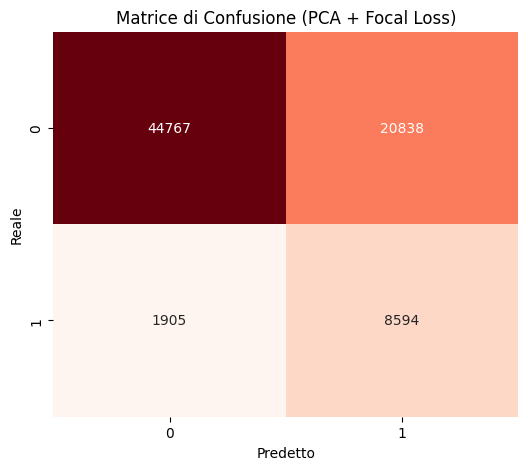

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     65605
           1       0.29      0.82      0.43     10499

    accuracy                           0.70     76104
   macro avg       0.63      0.75      0.61     76104
weighted avg       0.87      0.70      0.75     76104



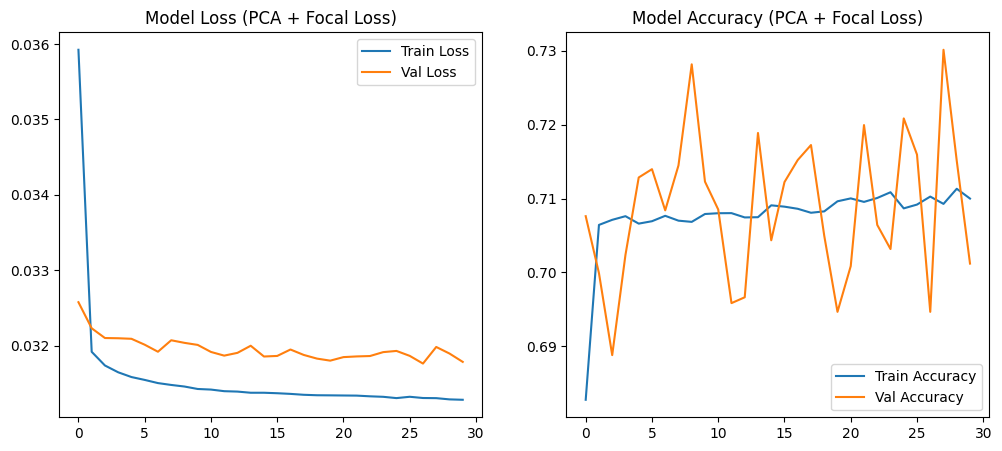

In [34]:
import tensorflow as tf

# Definizione corretta della Focal Loss per classificazione binaria
def focal_loss(gamma=2., alpha=0.25):
    """
    Focal Loss per classificazione binaria sbilanciata.
    
    Parameters:
    - gamma: focusing parameter (default=2.0). Maggiore è gamma, più il modello si concentra sugli esempi difficili
    - alpha: peso per la classe positiva (default=0.25). Per dati sbilanciati, usa alpha ≈ frequenza classe negativa
    """
    def focal_loss_fixed(y_true, y_pred):
        # Converti tutto a float32 per evitare problemi di tipo
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        # Binary Cross Entropy
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        
        # Focal Loss modulation
        # Per gli esempi della classe 1 (y_true=1): p_t = y_pred
        # Per gli esempi della classe 0 (y_true=0): p_t = 1 - y_pred
        p_t = tf.where(tf.equal(y_true, 1.0), y_pred, 1 - y_pred)
        
        # Alpha balancing (converti alpha a float32)
        alpha_f32 = tf.constant(alpha, dtype=tf.float32)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha_f32, 1 - alpha_f32)
        
        # Focal term: (1 - p_t)^gamma (converti gamma a float32)
        gamma_f32 = tf.constant(gamma, dtype=tf.float32)
        focal_weight = tf.pow(1. - p_t, gamma_f32)
        
        # Focal Loss finale
        focal_loss = alpha_t * focal_weight * bce
        
        return tf.reduce_mean(focal_loss)
    
    return focal_loss_fixed

# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# Calcola alpha ottimale basato sulla distribuzione delle classi
# alpha ≈ freq(classe 0) per dare più peso alla classe minoritaria (1)
class_freq = np.bincount(y_train_pca.astype(int))
alpha_optimal = float(class_freq[0] / (class_freq[0] + class_freq[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal:.3f}")

# 2. Creazione del Modello
model_pca_focal = Sequential()
model_pca_focal.add(Dense(16, input_shape=(14,), activation="relu"))
model_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
# Usa gamma=2.0 e alpha calcolato automaticamente
model_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal), 
    optimizer="adam", 
    metrics=["accuracy"]
)

# 4. Addestramento
history_pca_focal = model_pca_focal.fit(
    X_train_pca, y_train_pca,
    epochs=30, batch_size=64, verbose=1,
    validation_split=0.1
)

# 5. Valutazione
y_pred_probs_focal = model_pca_focal.predict(X_test_pca)
y_pred_focal = (y_pred_probs_focal > 0.5).astype("int32")

cm_focal = confusion_matrix(y_test_pca, y_pred_focal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_focal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (PCA + Focal Loss)")
plt.show()

print("Report di Classificazione:")
print(classification_report(y_test_pca, y_pred_focal))

# 6. Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_pca_focal.history['loss'], label='Train Loss')
plt.plot(history_pca_focal.history['val_loss'], label='Val Loss')
plt.title('Model Loss (PCA + Focal Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pca_focal.history['accuracy'], label='Train Accuracy')
plt.plot(history_pca_focal.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (PCA + Focal Loss)')
plt.legend()
plt.show()

## No PCA + Class Weights

Dimensioni Training Set: (177576, 21)
Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/30


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7026 - loss: 0.5306 - val_accuracy: 0.7104 - val_loss: 0.5120
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7079 - loss: 0.5062 - val_accuracy: 0.7227 - val_loss: 0.4975
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7119 - loss: 0.5039 - val_accuracy: 0.7201 - val_loss: 0.5020
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7126 - loss: 0.5029 - val_accuracy: 0.7236 - val_loss: 0.4971
Epoch 5/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7127 - loss: 0.5024 - val_accuracy: 0.7148 - val_loss: 0.5106
Epoch 6/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7126 - loss: 0.5021 - val_accuracy: 0.7158 - val_loss: 0.5154
Epoch 7/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7140 - loss: 0.5019 - val_accuracy: 0.7137 - val_loss: 0.5105
Epoch 8/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7140 - loss: 0.5015 - val_accurac

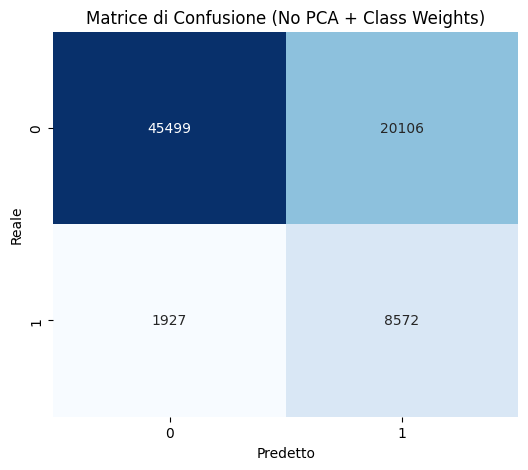

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     65605
           1       0.30      0.82      0.44     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



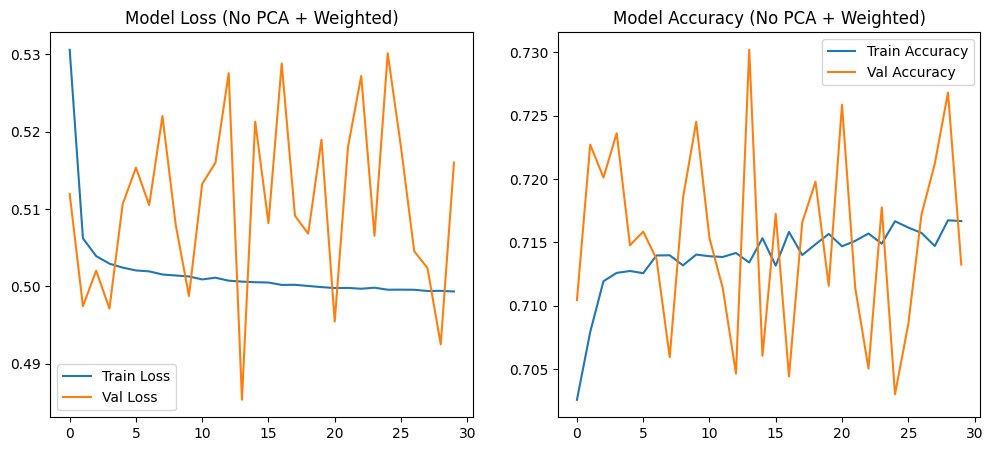

In [35]:
# 1. Data Preparation (No PCA - tutte le 21 feature)
X_no_pca = scaled_data
y = df["Diabetes_binary"].values

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_np.shape}")

# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_no_pca_weighted = Sequential()
model_no_pca_weighted.add(Dense(16, input_shape=(21,), activation="relu"))
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))

model_no_pca_weighted.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# 4. Addestramento con Class Weights
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train_np, y_train_np,
    epochs=30, batch_size=64, verbose=1,
    validation_split=0.1,
    class_weight=class_weights
)

# 5. Valutazione
y_pred_probs_weighted_np = model_no_pca_weighted.predict(X_test_np)
y_pred_weighted_np = (y_pred_probs_weighted_np > 0.5).astype("int32")

cm_weighted_np = confusion_matrix(y_test_np, y_pred_weighted_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted_np, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (No PCA + Class Weights)")
plt.show()

print("Report di Classificazione:")
print(classification_report(y_test_np, y_pred_weighted_np))

# 6. Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_no_pca_weighted.history['loss'], label='Train Loss')
plt.plot(history_no_pca_weighted.history['val_loss'], label='Val Loss')
plt.title('Model Loss (No PCA + Weighted)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_no_pca_weighted.history['accuracy'], label='Train Accuracy')
plt.plot(history_no_pca_weighted.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (No PCA + Weighted)')
plt.legend()
plt.show()

## No PCA + Focal Loss

Alpha ottimale calcolato: 0.860
Epoch 1/30


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7046 - loss: 0.0331 - val_accuracy: 0.7015 - val_loss: 0.0321
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7046 - loss: 0.0331 - val_accuracy: 0.7015 - val_loss: 0.0321
Epoch 2/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7075 - loss: 0.0313 - val_accuracy: 0.7118 - val_loss: 0.0317
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7075 - loss: 0.0313 - val_accuracy: 0.7118 - val_loss: 0.0317
Epoch 3/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7099 - loss: 0.0312 - val_accuracy: 0.7003 - val_loss: 0.0316
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7099 - loss: 0.0312 - val_accuracy: 0.7003 - val_loss: 0.0316
Epoch 4/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7112 - loss: 0.0311 - val_accuracy: 0.7102 - val_loss: 0.0315
Epoch 5/30
2498/2498 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7112 - loss: 0.0311 - val_accurac

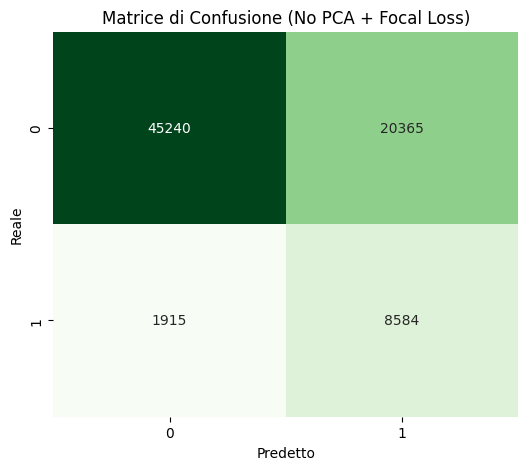

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     65605
           1       0.30      0.82      0.44     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



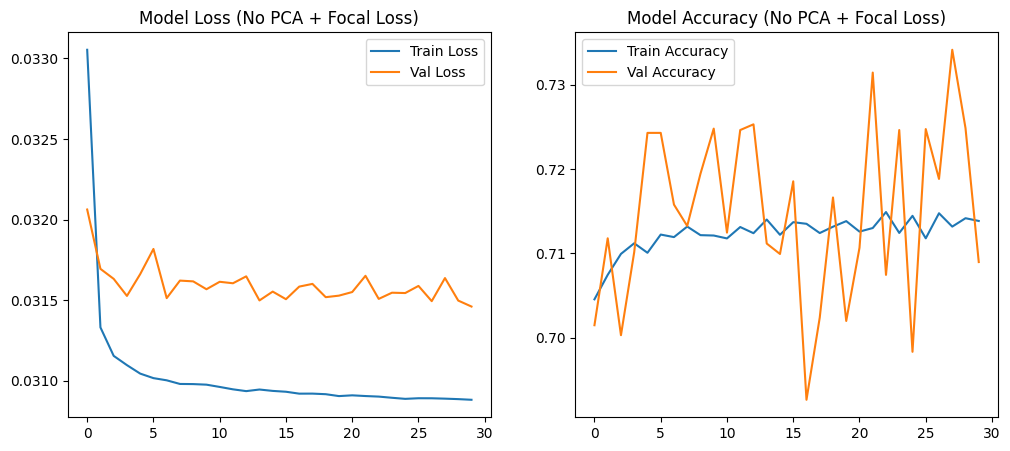

In [36]:
# 1. Data Preparation (No PCA - tutte le 21 feature)
X_no_pca = scaled_data
y = df["Diabetes_binary"].values

X_train_np_focal, X_test_np_focal, y_train_np_focal, y_test_np_focal = train_test_split(
    X_no_pca, y, test_size=0.3, random_state=42
)

# Calcola alpha ottimale basato sulla distribuzione delle classi
class_freq_np = np.bincount(y_train_np_focal.astype(int))
alpha_optimal_np = float(class_freq_np[0] / (class_freq_np[0] + class_freq_np[1]))
print(f"Alpha ottimale calcolato: {alpha_optimal_np:.3f}")

# 2. Creazione del Modello
model_no_pca_focal = Sequential()
model_no_pca_focal.add(Dense(16, input_shape=(21,), activation="relu"))
model_no_pca_focal.add(Dense(1, activation="sigmoid"))

# 3. Compilazione con Focal Loss
model_no_pca_focal.compile(
    loss=focal_loss(gamma=2.0, alpha=alpha_optimal_np), 
    optimizer="adam", 
    metrics=["accuracy"]
)

# 4. Addestramento
history_no_pca_focal = model_no_pca_focal.fit(
    X_train_np_focal, y_train_np_focal,
    epochs=30, batch_size=64, verbose=1,
    validation_split=0.1
)

# 5. Valutazione
y_pred_probs_focal_np = model_no_pca_focal.predict(X_test_np_focal)
y_pred_focal_np = (y_pred_probs_focal_np > 0.5).astype("int32")

cm_focal_np = confusion_matrix(y_test_np_focal, y_pred_focal_np)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_focal_np, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione (No PCA + Focal Loss)")
plt.show()

print("Report di Classificazione:")
print(classification_report(y_test_np_focal, y_pred_focal_np))

# 6. Curve di Loss e Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_no_pca_focal.history['loss'], label='Train Loss')
plt.plot(history_no_pca_focal.history['val_loss'], label='Val Loss')
plt.title('Model Loss (No PCA + Focal Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_no_pca_focal.history['accuracy'], label='Train Accuracy')
plt.plot(history_no_pca_focal.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (No PCA + Focal Loss)')
plt.legend()
plt.show()

# Support Vector Machines